In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/bank_loan_classification_dataset - bank_loan_classification_dataset.csv')
df.head()

,customer_id,age,gender,region,marital_status,education_level,employment_type,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_purpose,loan_approved
0,CUST000001,59,Male,North,Single,Bachelor,Business,9.25,721,7,4,37.83,7.67,13.35,4,7.26,Car,0
1,CUST000002,56,Male,North,Single,High School,Student,13.96,605,1,3,56.62,26.70,6.11,8,17.23,Home,0
2,CUST000003,47,Male,South,Married,Bachelor,Salaried,6.94,705,27,3,25.15,26.73,9.19,6,6.65,Personal,0
3,CUST000004,23,Male,West,Married,High School,Business,14.09,746,8,1,57.19,10.19,16.95,6,6.25,Car,0
4,CUST000005,28,Female,East,Single,Bachelor,Self-Employed,16.11,582,1,5,33.60,4.37,21.51,9,9.18,Education,0


##Step 2: explore dataset
--Dataset Shape
--Dataset Information
--Checking Missing Values




In [ ]:
df.shape

(22000, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            22000 non-null  object 
 1   age                    22000 non-null  int64  
 2   gender                 22000 non-null  object 
 3   region                 22000 non-null  object 
 4   marital_status         22000 non-null  object 
 5   education_level        22000 non-null  object 
 6   employment_type        22000 non-null  object 
 7   annual_income_lakh     22000 non-null  float64
 8   credit_score           22000 non-null  int64  
 9   years_employed         22000 non-null  int64  
 10  existing_loans         22000 non-null  int64  
 11  debt_to_income_ratio   22000 non-null  float64
 12  loan_amount_lakh       22000 non-null  float64
 13  interest_rate_percent  22000 non-null  float64
 14  missed_payments        22000 non-null  int64  
 15  sa

In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
region,0
marital_status,0
education_level,0
employment_type,0
annual_income_lakh,0
credit_score,0
years_employed,0


In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'marital_status',
       'education_level', 'employment_type', 'annual_income_lakh',
       'credit_score', 'years_employed', 'existing_loans',
       'debt_to_income_ratio', 'loan_amount_lakh', 'interest_rate_percent',
       'missed_payments', 'savings_balance_lakh', 'loan_purpose',
       'loan_approved'],
      dtype='object')

##Step 3: Exploratory Data Analysis (EDA)

*   Target Variable Distribution
*   Correlation Heatmap
*   Credit Score vs Loan Approval  

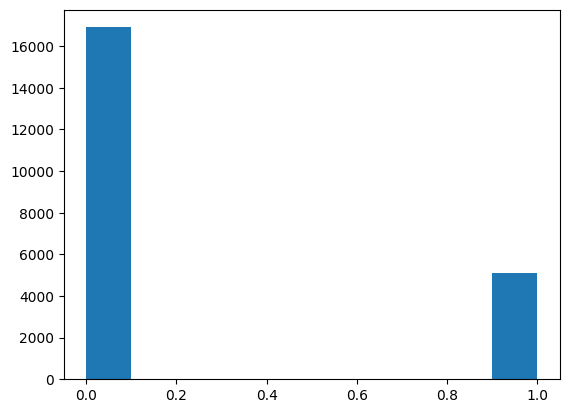

In [ ]:
plt.hist(df['loan_approved'])
plt.show()

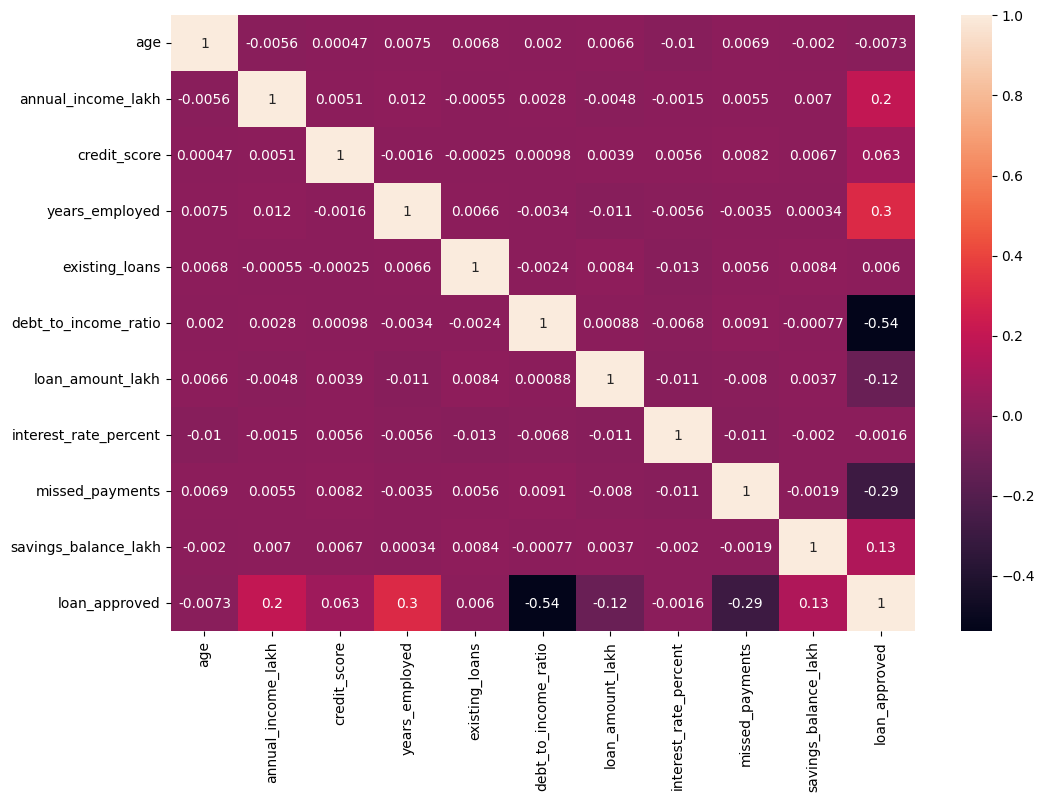

In [ ]:
core = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(core,annot=True)
plt.show()

In [ ]:
#finded range
print(df['credit_score'].min())
print(df['credit_score'].max())

364
900


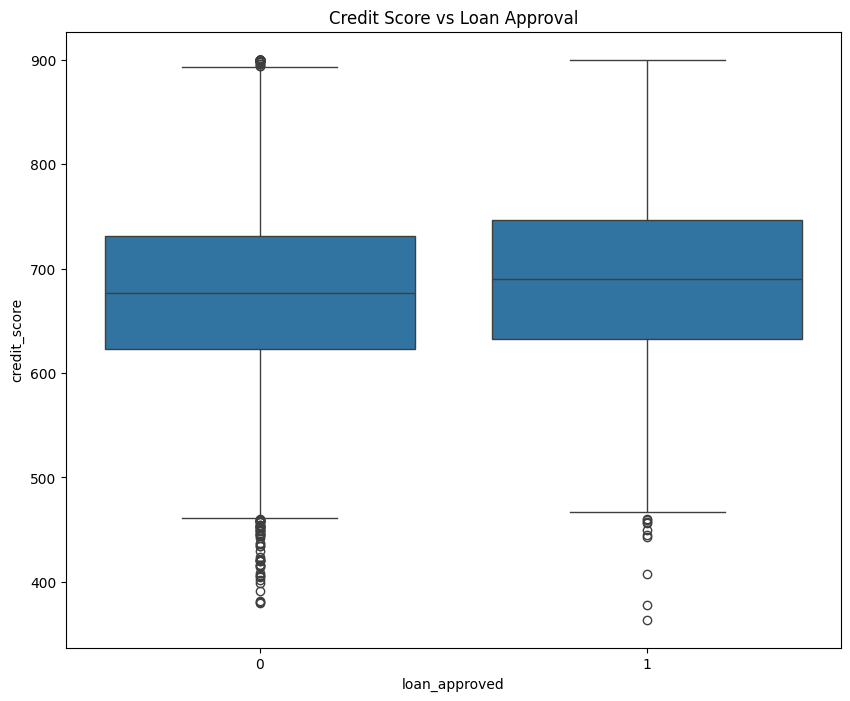

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data = df, x =df['loan_approved'],y=df['credit_score'])
plt.title("Credit Score vs Loan Approval")
plt.show()

In [ ]:
# 300 to 500 -- %
# 500 to 700 -- %
# 700 to 900 -- %
# finding the range
range1 = df[(df['credit_score'] >= 300)  & (df['credit_score'] <= 500)]
range2 = df[(df['credit_score'] >= 500)  & (df['credit_score'] <= 700)]
range3 = df[(df['credit_score'] >= 700)  & (df['credit_score'] <= 900)]
print(len(range1))
print(len(range2))
print(len(range3))

261
12931
8927


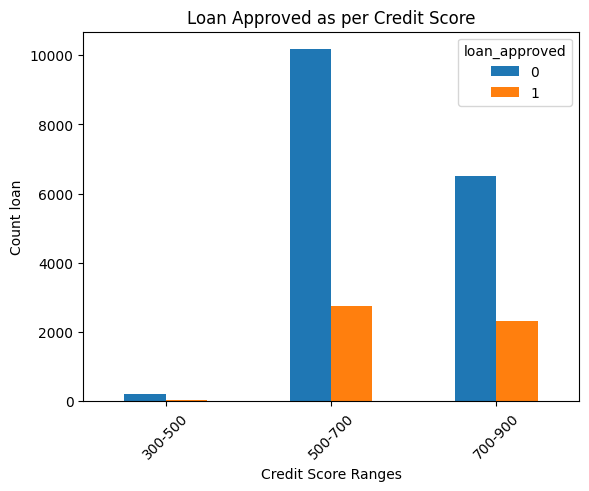

In [ ]:
ct = pd.crosstab(
    pd.cut(
        df['credit_score'],
        bins =[300,500,700,900],
        labels =['300-500','500-700','700-900']
    ),
    df['loan_approved']
)
ct.plot(kind='bar')
plt.xlabel('Credit Score Ranges')
plt.ylabel('Count loan')
plt.xticks(rotation=45)
plt.title('Loan Approved as per Credit Score')
plt.show()

## Step4 Feature Engineering
*   Loan to income ratio
*   financial stablitty score
*   debt burden score


     



In [ ]:
# Loan debt ration
df.head()

,customer_id,age,gender,region,marital_status,education_level,employment_type,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_purpose,loan_approved
0,CUST000001,59,Male,North,Single,Bachelor,Business,9.25,721,7,4,37.83,7.67,13.35,4,7.26,Car,0
1,CUST000002,56,Male,North,Single,High School,Student,13.96,605,1,3,56.62,26.70,6.11,8,17.23,Home,0
2,CUST000003,47,Male,South,Married,Bachelor,Salaried,6.94,705,27,3,25.15,26.73,9.19,6,6.65,Personal,0
3,CUST000004,23,Male,West,Married,High School,Business,14.09,746,8,1,57.19,10.19,16.95,6,6.25,Car,0
4,CUST000005,28,Female,East,Single,Bachelor,Self-Employed,16.11,582,1,5,33.60,4.37,21.51,9,9.18,Education,0


In [ ]:
df['loan_debt_ratio'] = df['annual_income_lakh']/(df['years_employed']+1)
df['financial_stability_score'] = ((df['credit_score']*0.5)+(df['savings_balance_lakh']*10)-(df['missed_payments']* 5))
df['debt_burden_ratio'] = (df['debt_to_income_ratio']*(df['existing_loans'] + 1))

## Step 5  Splitting the features and target


In [ ]:
x = df.drop(columns=['loan_approved','customer_id'])
y = df['loan_approved']


In [ ]:
#numerical and categorical columns
numerical_cols = x.select_dtypes(exclude='object').columns
categorical_cols = x.select_dtypes(include='object').columns

print('Categorical columns: ',categorical_cols)
print('Numerical columns: ',numerical_cols)

Categorical columns:  Index(['gender', 'region', 'marital_status', 'education_level',
       'employment_type', 'loan_purpose'],
      dtype='object')
Numerical columns:  Index(['age', 'annual_income_lakh', 'credit_score', 'years_employed',
       'existing_loans', 'debt_to_income_ratio', 'loan_amount_lakh',
       'interest_rate_percent', 'missed_payments', 'savings_balance_lakh',
       'loan_debt_ratio', 'financial_stability_score', 'debt_burden_ratio'],
      dtype='object')


# Preprocessing Pipeline

We will:
- Handle missing values
- Encode categorical data
- Scale numerical data


In [ ]:
label_cols = ['gender','marital_status']
one_hot_cols = ['region','education_level','employment_type','loan_purpose']

num_pip =Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaller',StandardScaler())
])
label_pip =Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('label',OrdinalEncoder())
])
one_hot_pip =Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('label',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num',num_pip,numerical_cols),
    ('label',label_pip,label_cols),
    ('one_hot',one_hot_pip,one_hot_cols)
])

In [ ]:
# train test Split
Xtrain,Xtest,Ytrain,Ytest =train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
def evaluate_model(model_name,Ytest,predictions,probabilities=None):
  accuracy = accuracy_score(Ytest,predictions)
  precision = precision_score(Ytest,predictions)
  recall = recall_score(Ytest,predictions)
  f1 = f1_score(Ytest,predictions)

  results = {
      'Model' :model_name,
      'Accuracy' : accuracy,
      'Precison':precision,
      'Recall' :recall,
      'F1' : f1,
  }
  return results;

## Performing the Logistic Regression

In [ ]:
logistic_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])
logistic_pipeline.fit(Xtrain,Ytrain)
logistic_prediction = logistic_pipeline.predict(Xtest)
logistic_prob = logistic_pipeline.predict_proba(Xtest)[:,1]
logistic_results = evaluate_model(
    'Logistic Regression',
    Ytest,
    logistic_prediction,
    logistic_prob
)
logistic_results


{'Model': 'Logistic Regression',
 'Accuracy': 0.9969090909090909,
 'Precison': 0.9959316517493898,
 'Recall': 0.9902912621359223,
 'F1': 0.993103448275862}

## Performing the KNN

In [ ]:
knn_pipeline = Pipeline([
 ('preprocessor',preprocessor),
 ('KNN',KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(Xtrain,Ytrain)
knn_predict = knn_pipeline.predict(Xtest)
knn_prob = knn_pipeline.predict_proba(Xtest)[:,1]
knn_result = evaluate_model(
    'KNeighborsClassifier',
    Ytest,
    knn_predict
)
knn_result

{'Model': 'KNeighborsClassifier',
 'Accuracy': 0.9107272727272727,
 'Precison': 0.8557784145176696,
 'Recall': 0.7249190938511327,
 'F1': 0.7849321068769164}

## performing the Gussian Naive Bayes

In [ ]:
gussian_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('Gussian',GaussianNB())
])
gussian_pipeline.fit(Xtrain,Ytrain)
gussian_predict = gussian_pipeline.predict(Xtest)
gussian_prob = gussian_pipeline.predict_proba(Xtest)[:,1]
gussian_result = evaluate_model(
    'Gussian Naive Bayes',
    Ytest,
    gussian_predict,
    gussian_prob
)
gussian_result


{'Model': 'Gussian Naive Bayes',
 'Accuracy': 0.881090909090909,
 'Precison': 0.6798516687268232,
 'Recall': 0.889967637540453,
 'F1': 0.7708479327259986}

## Performing the Random Forest Classifier

In [ ]:
rand_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('Random Forest',RandomForestClassifier(random_state=42))
])
rand_pipeline.fit(Xtrain,Ytrain)
rand_predict = rand_pipeline.predict(Xtest)
rand_prob = rand_pipeline.predict_proba(Xtest)[:,1]
rand_result = evaluate_model(
    'Random Forest Classifier',
    Ytest,
    rand_predict,
    rand_prob
    )
rand_result

{'Model': 'Random Forest Classifier',
 'Accuracy': 0.9485454545454546,
 'Precison': 0.9516587677725118,
 'Recall': 0.8122977346278317,
 'F1': 0.8764731558271497}

## Comparing All the models

In [ ]:
result_df = pd.DataFrame([
    logistic_results,
    knn_result,
    gussian_result,
    rand_result
])
result_df

,Model,Accuracy,Precison,Recall,F1
0,Logistic Regression,0.996909,0.995932,0.990291,0.993103
1,KNeighborsClassifier,0.910727,0.855778,0.724919,0.784932
2,Gussian Naive Bayes,0.881091,0.679852,0.889968,0.770848
3,Random Forest Classifier,0.948545,0.951659,0.812298,0.876473


## Accuraccy Comaprision

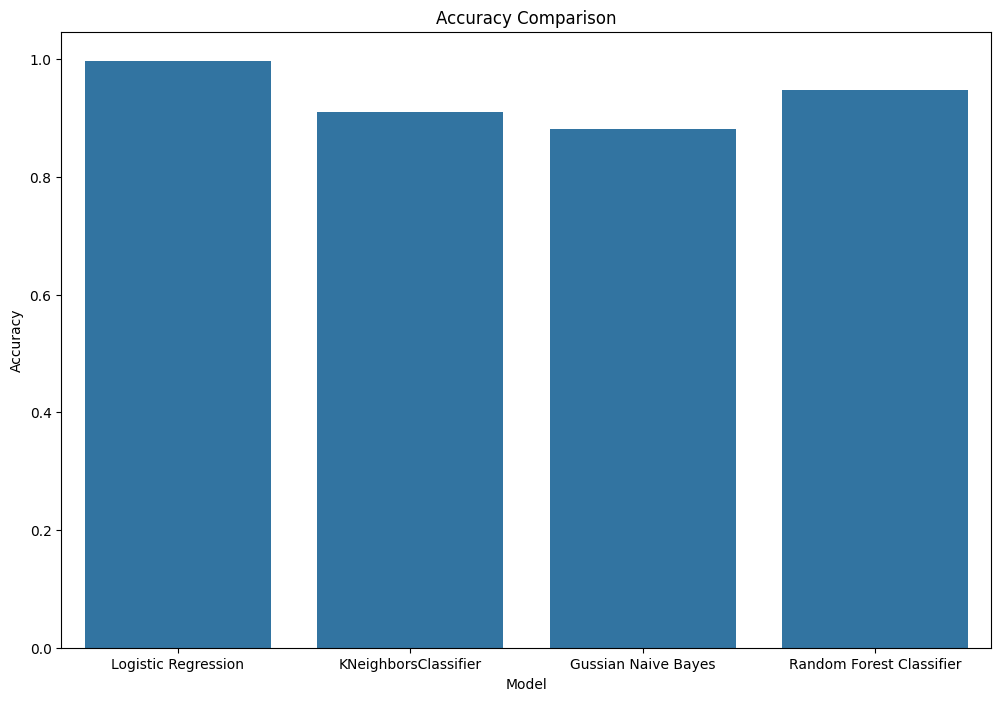

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(data = result_df,x=result_df['Model'],y=result_df['Accuracy'])
plt.title("Accuracy Comparison")
plt.show()